# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 02: Análise Exploratória de Dados (EDA)**</font>

## <font color='cyan'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='cyan'>ciano</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_02_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='cyan'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: data de criação, domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.
- #### <font color='cyan'>Becker, B. & Kohavi, R. (1996). Adult Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.</font>

O Adult Dataset, criado em 1996 por Barry Becker e Ronny Kohavi e disponibilizado no UCI Machine Learning Repository, é um conjunto de dados do domínio das ciências sociais e mineração de dados, amplamente utilizado em pesquisas de aprendizado de máquina e classificação. Ele foi extraído de registros do Censo dos Estados Unidos de 1994 e tem como objetivo permitir a construção de modelos capazes de prever se a renda anual de um indivíduo ultrapassa US$50.000 com base em características demográficas e socioeconômicas. A base contém informações como idade, nível de escolaridade, estado civil, ocupação, classe de trabalho, sexo, raça, país de origem, horas trabalhadas por semana e ganhos ou perdas de capital.

## <font color='green'>Preparação</font>

### <font color='cyan'>Dataset: Becker, B. & Kohavi, R. (1996). Adult Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20.</font>

In [2]:
!pip install pandas ucimlrepo

In [3]:
import pandas as pd

from pprint import pprint
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

In [4]:
pprint(adult.metadata)

{'abstract': 'Predict whether annual income of an individual exceeds $50K/yr '
             'based on census data. Also known as "Census Income" dataset. ',
 'additional_info': {'citation': None,
                     'funded_by': None,
                     'instances_represent': None,
                     'preprocessing_description': None,
                     'purpose': None,
                     'recommended_data_splits': None,
                     'sensitive_data': None,
                     'summary': 'Extraction was done by Barry Becker from the '
                                '1994 Census database.  A set of reasonably '
                                'clean records was extracted using the '
                                'following conditions: ((AAGE>16) && (AGI>100) '
                                '&& (AFNLWGT>1)&& (HRSWK>0))\n'
                                '\n'
                                'Prediction task is to determine whether a '
                               

In [5]:
adult.variables

,name,role,type,demographic,description,units,missing_values
0,age,Feature,Integer,Age,N/A,None,no
1,workclass,Feature,Categorical,Income,"Private, Self-emp-not-inc, Self-emp-inc, Feder...",None,yes
2,fnlwgt,Feature,Integer,None,None,None,no
3,education,Feature,Categorical,Education Level,"Bachelors, Some-college, 11th, HS-grad, Prof-...",None,no
4,education-num,Feature,Integer,Education Level,None,None,no
5,marital-status,Feature,Categorical,Other,"Married-civ-spouse, Divorced, Never-married, S...",None,no
6,occupation,Feature,Categorical,Other,"Tech-support, Craft-repair, Other-service, Sal...",None,yes
7,relationship,Feature,Categorical,Other,"Wife, Own-child, Husband, Not-in-family, Other...",None,no
8,race,Feature,Categorical,Race,"White, Asian-Pac-Islander, Amer-Indian-Eskimo,...",None,no
9,sex,Feature,Binary,Sex,"Female, Male.",None,no


In [6]:
X = adult.data.features
y = adult.data.targets

df = pd.concat([X, y], axis='columns')

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


## <font color='green'>**2.1 Conjuntos de Dados**</font>

### <font color='cyan'>Q1: Exiba 10 amostras aleatórias do conjunto de dados.</font>

In [7]:
import pandas as pd

from pprint import pprint
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

In [8]:
X = adult.data.features
y = adult.data.targets

df = pd.concat([X, y], axis='columns')

df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


### <font color='cyan'>Q2: Quantas amostras o conjunto de dados possui?</font>

In [9]:
print(len(df))

48842


### <font color='cyan'>Q3: Quantas características o conjunto de dados possui?</font>

In [10]:
print(df.shape[1])

15


### <font color='cyan'>Q4: O conjunto de dados possui características numéricas? Se sim, escreva seu(s) nome(s) e classifique-a(s) como contínua(s) e/ou discreta(s).</font>
- #### <font color='cyan'>Observação: considere que uma caraterística numérica é discreta se possui menos que 50 valores únicos.</font>

In [11]:
numeric_features = df.select_dtypes(include=['int64', 'float64'])
print("Características Numéricas:")
for column in numeric_features.columns:
    unique_values_count = df[column].nunique()
    if unique_values_count < 50:
        print(f"- {column}: Discreta (valores únicos: {unique_values_count})")
    else:
        print(f"- {column}: Contínua (valores únicos: {unique_values_count})")

Características Numéricas:
- age: Contínua (valores únicos: 74)
- fnlwgt: Contínua (valores únicos: 28523)
- education-num: Discreta (valores únicos: 16)
- capital-gain: Contínua (valores únicos: 123)
- capital-loss: Contínua (valores únicos: 99)
- hours-per-week: Contínua (valores únicos: 96)


### <font color='cyan'>Q5: O conjunto de dados possui características categóricas? Se sim, escreva seu(s) nome(s) e sua(s) quantidade(s) de valores únicos.</font>

In [12]:
categorical_features = df.select_dtypes(include=['object'])
print("Características Categóricas:")
for column in categorical_features.columns:
    unique_values_count = df[column].nunique()
    print(f"- {column}: {unique_values_count} valores únicos")

Características Categóricas:
- workclass: 9 valores únicos
- education: 16 valores únicos
- marital-status: 7 valores únicos
- occupation: 15 valores únicos
- relationship: 6 valores únicos
- race: 5 valores únicos
- sex: 2 valores únicos
- native-country: 42 valores únicos
- income: 4 valores únicos


## <font color='green'>**2.2 Estatística Descritiva Básica**</font>

### <font color='cyan'> Q6: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

capital-gain

### <font color='cyan'> Q7: Calcule e mostre suas Medidas de Tendência Central (média, mediana e moda).</font>

In [13]:
coluna = "capital-gain"

media = df[coluna].mean()
mediana = df[coluna].median()
moda = df[coluna].mode()[0]

print("Média:", media)
print("Mediana:", mediana)
print("Moda:", moda)

Média: 1079.0676262233324
Mediana: 0.0
Moda: 0


### <font color='cyan'> Q8: Calcule e mostre suas Medidas de Dispersão (mínimo, máximo e amplitude).</font>

In [14]:
minimo = df[coluna].min()
maximo = df[coluna].max()
amplitude = maximo - minimo

print("Mínimo:", minimo)
print("Máximo:", maximo)
print("Amplitude:", amplitude)

Mínimo: 0
Máximo: 99999
Amplitude: 99999


## <font color='green'>**2.3 Análise Univariada**</font>

### <font color='cyan'> Q9: Escolha uma característica categórica do conjunto de dados. Escreva seu nome a seguir.</font>

education

### <font color='cyan'> Q10: Crie e exiba uma Tabela de Frequência e/ou um Gráfico de Barras para a característica escolhida.</font>

In [15]:
tabela_freq = df['education'].value_counts()

print(tabela_freq)

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64


### <font color='cyan'> Q11: Escolha uma característica numérica do conjunto de dados. Escreva seu nome a seguir.</font>

capital-loss

### <font color='cyan'> Q13: Crie e exiba um Histograma e/ou uma Estimativa de Densidade por Kernel (KDE) para a característica escolhida.</font>

NameError: name 'plt' is not defined

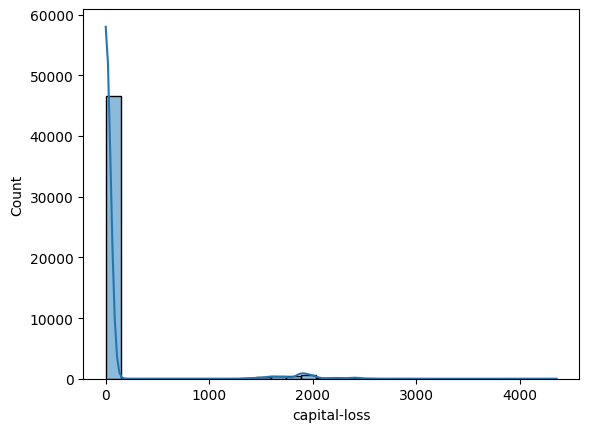

In [16]:
import seaborn as sns

sns.histplot(df['capital-loss'], bins=30, kde=True)

plt.title("Distribuição de Capital Loss")
plt.xlabel("Capital Loss")
plt.ylabel("Frequência")

plt.show()

## <font color='green'>**2.4 Análise Bivariada**</font>



### <font color='cyan'> Q14: Escolha duas características do conjuntos de dados. Escreva seus nome a seguir.</font>

capital-loss, hours-per-week

### <font color='cyan'> Q15: De acordo com os tipos das características escolhidas, produza pelo menos uma visualização de análise bivariada.</font>

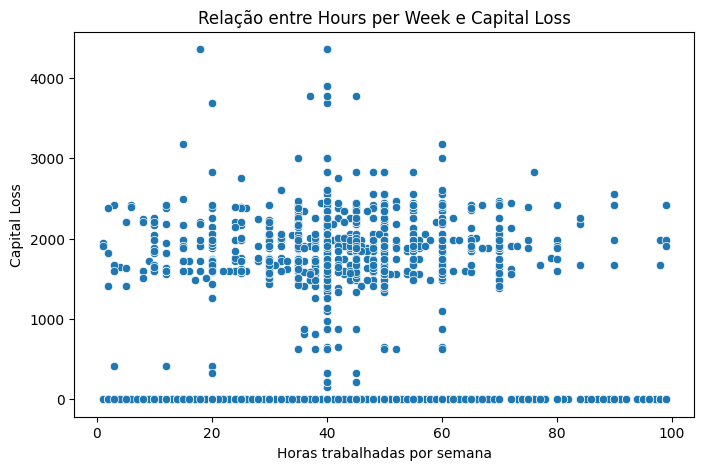

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="hours-per-week",
    y="capital-loss"
)

plt.title("Relação entre Hours per Week e Capital Loss")
plt.xlabel("Horas trabalhadas por semana")
plt.ylabel("Capital Loss")

plt.show()

## <font color='green'>**2.5 Identificação de Problemas nos Dados**</font>

### <font color='cyan'> Q16: Inspecione o conjuntos de dados para verificar se há:</font>
- #### <font color='cyan'> Dados Ausentes;</font>
- #### <font color='cyan'> Valores Atípicos (via IQR);</font>
- #### <font color='cyan'> Valores Duplicados;</font>
### <font color='cyan'> Reporte sua(s) descoberta(s) a seguir.</font>

In [17]:
print("Dados ausentes por coluna:")
print(df.isnull().sum())


duplicados = df.duplicated().sum()
print("\nNúmero de valores duplicados:", duplicados)

numericas = df.select_dtypes(include=['int64','float64'])

outliers = {}

for col in numericas.columns:
    Q1 = numericas[col].quantile(0.25)
    Q3 = numericas[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers[col] = ((numericas[col] < limite_inferior) | (numericas[col] > limite_superior)).sum()

print("\nQuantidade de valores atípicos por coluna:")
for col, val in outliers.items():
    print(f"{col}: {val}")

Dados ausentes por coluna:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Número de valores duplicados: 29

Quantidade de valores atípicos por coluna:
age: 216
fnlwgt: 1453
education-num: 1794
capital-gain: 4035
capital-loss: 2282
hours-per-week: 13496


### <font color='cyan'> Q17: Caso um problema tenha sido encontrado, proponha uma solução para ele.</font>
### <font color='cyan'> Exiba o conjunto de dados antes e depois da solução, enfatizando as mudanças.</font>

In [18]:
print("Tamanho do dataset antes:", df.shape)

print("\nDados ausentes antes:")
print(df.isnull().sum())

print("\nDuplicados antes:")
print(df.duplicated().sum())

print("\nAmostra antes da limpeza:")
print(df.head())

df_limpo = df.dropna()

print("\nTamanho do dataset depois:", df_limpo.shape)

print("\nDados ausentes depois:")
print(df_limpo.isnull().sum())

print("\nDuplicados depois:")
print(df_limpo.duplicated().sum())

print("\nAmostra depois da limpeza:")
print(df_limpo.head())

Tamanho do dataset antes: (48842, 15)

Dados ausentes antes:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Duplicados antes:
29

Amostra antes da limpeza:
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    E

## <font color='green'>**2.6 Correlação Simples**</font>

### <font color='cyan'> Q18: Escolha duas características numéricas do conjuntos de dados. Escreva seus nomes a seguir.</font>

capital-gain, hours-per-week

### <font color='cyan'> Q19: Calcule e exiba o Coeficiente de Correlação de Pearson ($r$) entre elas.</font>

In [19]:
coluna1 = "capital-gain"
coluna2 = "hours-per-week"

correlacao = df[[coluna1, coluna2]].corr(method="pearson")

print("Coeficiente de Correlação de Pearson:")
print(correlacao)

Coeficiente de Correlação de Pearson:
                capital-gain  hours-per-week
capital-gain        1.000000        0.082157
hours-per-week      0.082157        1.000000


### <font color='cyan'> Q20: Interprete o coeficiente de correlação, em termos de sinal e magnitude.</font>

O coeficiente de correlação de Pearson mede a relação linear entre duas variáveis numéricas. O valor obtido foi próximo de 0, indicando uma correlação muito fraca ou inexistente entre capital-gain e hours-per-week. Isso significa que a quantidade de horas trabalhadas por semana não possui uma relação linear significativa com os ganhos de capital no conjunto de dados.